# 10 · Descriptive Context — What the Data Shows Beyond H1

**Thesis role:** Bounded descriptive context. Organised by which contribution each finding supports.

- **Part I** (§1) — motivates Contribution 2 (cast-adjusted measure)
- **Part II** (§2–3) — payoff of Contribution 1 (directed weighted addressee data)
- **Appendix** (§A–D) — supporting material; not core to the narrative

**Requires:** `09_analysis.ipynb` run first.

## 0. Setup

In [18]:
from pathlib import Path
import sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats

CLEAN = Path('..').resolve()
sys.path.insert(0, str(CLEAN / 'analysis' / 'h1_homophily'))
from _common import GENDER_PALETTE, GENDER_ORDER, set_style, cliffs_delta, mannwhitney, power_note
set_style()

DATA = CLEAN / 'data' / '02_processed'
TBL  = CLEAN / 'analysis' / 'h1_homophily' / 'tables_n17'
FIG  = CLEAN / 'analysis' / 'h1_homophily' / 'figures_n17'

DROP_FILMS  = {'soul_2020'}
DROP_PROTAG = ('monsters_inc_2001', 'Mike')
def apply_conventions(d):
    d = d[~d['film_id'].isin(DROP_FILMS)].copy()
    d = d[~((d['film_id']==DROP_PROTAG[0]) & (d['protagonist']==DROP_PROTAG[1]))].copy()
    return d.reset_index(drop=True)

# Load base features
df = apply_conventions(pd.read_csv(DATA / 'film_features_all_n17.csv'))

# Load social features (from notebook 08)
soc = pd.read_csv(DATA / 'film_features_social.csv')
soc = apply_conventions(soc)
df = df.merge(soc[['film_id','protagonist','out_in_ratio','pct_addressed_by_male',
                    'best_friend','bf_gender','bf_ratio_pct']], on=['film_id','protagonist'], how='left')

print(f"N={len(df)}  F={(df.lead_gender=='F').sum()}  M={(df.lead_gender=='M').sum()}")
df[['film_title','protagonist','lead_gender']].to_string(index=False)


N=17  F=8  M=9


'               film_title protagonist lead_gender\nBeauty & the Beast (1991)       Belle           F\n             Mulan (1998)       Mulan           F\n            Frozen (2013)        Anna           F\n        Inside Out (2015)         Joy           F\n          Zootopia (2016)       Hopps           F\n           Encanto (2021)     Mirabel           F\n              Raya (2021)        Raya           F\n         Elemental (2023)       Ember           F\n         Toy Story (1995)       Woody           M\n      Monsters Inc (2001)      Sulley           M\n      Finding Nemo (2003)      Marlin           M\n                Up (2009)        Carl           M\n       Toy Story 3 (2010)       Woody           M\n            Cars 2 (2011)       Mater           M\n              Coco (2017)      Miguel           M\n     Incredibles 2 (2018)         Bob           M\n            Onward (2020)         Ian           M'

---
# PART I — Motivates Contribution 2: why cast adjustment matters

*The cast composition gap is the confound the cast-adjusted measure removes.*

## 1. Cast composition gap

**The finding before the finding.** Cast adjustment removes the raw H1 gap — but the cast
composition difference that makes adjustment necessary is *itself* a structural fact about
the corpus. Male-led films are built with predominantly male casts; female-led films are
more gender-balanced. This is not protagonist behaviour — it is a writing choice.


In [19]:
# Compute % female in cast from betweenness_null.csv (has gender for each character)
cast_rows = []
for _, r in df.iterrows():
    btw_path = DATA / r.film_id / 'betweenness_null.csv'
    if not btw_path.exists():
        continue
    btw = pd.read_csv(btw_path)
    # exclude protagonist
    btw = btw[btw['character'].str.lower() != r.protagonist.lower()]
    if len(btw) == 0:
        continue
    pct_female = (btw['gender'] == 'F').mean()
    cast_rows.append({'film_id': r.film_id, 'film_title': r.film_title,
                      'lead_gender': r.lead_gender, 'cast_pct_female': pct_female,
                      'cast_pct_male': 1 - pct_female})

cast_df = pd.DataFrame(cast_rows)

F_cast = cast_df[cast_df.lead_gender=='F']['cast_pct_female'].values
M_cast = cast_df[cast_df.lead_gender=='M']['cast_pct_female'].values

print(f"Female-led films — median % female in cast: {np.median(F_cast):.0%}")
print(f"Male-led films   — median % female in cast: {np.median(M_cast):.0%}")
print(f"Cliff's delta: {cliffs_delta(F_cast, M_cast):+.3f}")
print(f"Mann-Whitney p: {mannwhitney(F_cast, M_cast)['p']:.4f}")
print()
print(cast_df[['film_title','lead_gender','cast_pct_female']].round(2).sort_values('lead_gender').to_string(index=False))


Female-led films — median % female in cast: 37%
Male-led films   — median % female in cast: 27%
Cliff's delta: +0.333
Mann-Whitney p: 0.2766

               film_title lead_gender  cast_pct_female
Beauty & the Beast (1991)           F             0.25
             Mulan (1998)           F             0.23
            Frozen (2013)           F             0.27
        Inside Out (2015)           F             0.55
          Zootopia (2016)           F             0.33
           Encanto (2021)           F             0.62
              Raya (2021)           F             0.56
         Elemental (2023)           F             0.40
              Coco (2017)           M             0.37
            Cars 2 (2011)           M             0.10
       Toy Story 3 (2010)           M             0.35
         Toy Story (1995)           M             0.25
      Finding Nemo (2003)           M             0.27
      Monsters Inc (2001)           M             0.21
     Incredibles 2 (2018)        

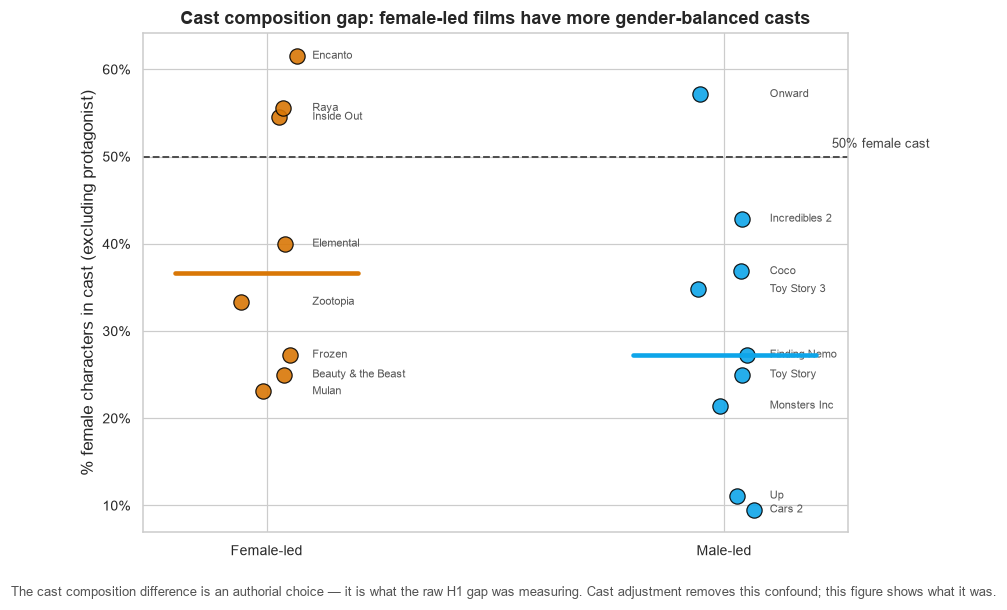

In [20]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for i, g in enumerate(GENDER_ORDER):
    sub = cast_df[cast_df.lead_gender == g]
    x = np.full(len(sub), i) + np.random.default_rng(42).uniform(-0.07, 0.07, len(sub))
    ax.scatter(x, sub.cast_pct_female, s=100, color=GENDER_PALETTE[g],
               edgecolor='black', lw=0.8, zorder=3, alpha=0.9)
    med = sub.cast_pct_female.median()
    ax.plot([i-0.2, i+0.2], [med, med], color=GENDER_PALETTE[g], lw=3, zorder=4)
    for _, r in sub.iterrows():
        ax.annotate(r.film_title.split(' (')[0], (i + 0.10, r.cast_pct_female),
                    fontsize=7, va='center', color='#555')

ax.axhline(0.5, color='#444', lw=1.2, ls='--')
ax.text(1.45, 0.51, '50% female cast', fontsize=8.5, color='#444', ha='right')
ax.set_xticks([0, 1]); ax.set_xticklabels(['Female-led', 'Male-led'])
ax.set_ylabel('% female characters in cast (excluding protagonist)')
ax.set_title('Cast composition gap: female-led films have more gender-balanced casts')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
fig.text(0.5, 0.005,
    "The cast composition difference is an authorial choice — it is what the raw H1 gap was measuring. "
    "Cast adjustment removes this confound; this figure shows what it was.",
    ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(FIG / 'fig_desc_cast_composition.png', dpi=150)
fig.savefig(FIG / 'fig_desc_cast_composition.pdf')
plt.show()


**How to read.** Each dot = one film's cast (excluding protagonist), y = % female characters.
Female-led films cluster near 50% (more balanced casts); male-led films cluster near 20–30% (predominantly male).
This is not the protagonist's behaviour — it is the writing context they were placed in.
The raw H1 gap (Cliff's δ = −0.94) was measuring this, not protagonist gender preference.


---
# PART II — Payoff of Contribution 1: what directed weighted data reveals

*These findings are only possible with addressee-tagged directed networks.*
*Scene co-occurrence cannot produce them.*

---
## 2. Dialogue economy — who speaks to whom by gender?

**The clearest gender pattern in the corpus.** Using directed weighted networks, we decompose all dialogue into four flows: F→F, F→M, M→F, M→M. The contrast between F-led and M-led films is stark and immediately visible.

This requires directed data: co-occurrence gives you F-M ties but cannot distinguish F→M from M→F.

F-led medians: {'FF': 0.171, 'FM': 0.257, 'MF': 0.316, 'MM': 0.064}
M-led medians: {'FF': 0.004, 'FM': 0.166, 'MF': 0.149, 'MM': 0.682}


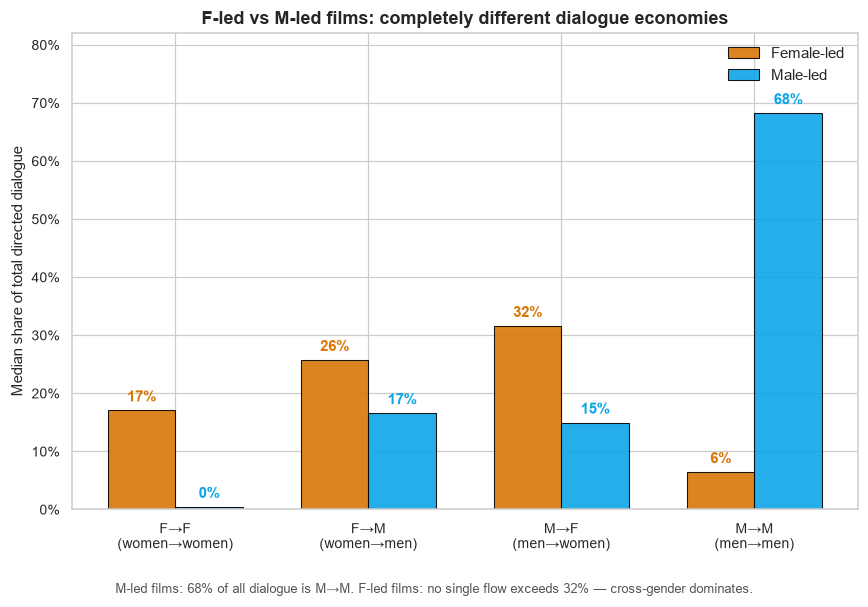

In [21]:
import matplotlib.patches as mpatches

# Compute gender flow from raw edges (using betweenness_null.csv for gender map)
flow_rows = []
for _, r in df.iterrows():
    ep = DATA / r.film_id / 'network_edges.csv'
    bp = DATA / r.film_id / 'betweenness_null.csv'
    if not ep.exists() or not bp.exists(): continue
    edges = pd.read_csv(ep)
    btw   = pd.read_csv(bp)[['character','gender']].dropna()
    gmap  = dict(zip(btw['character'], btw['gender']))
    edges['spk_g'] = edges['speaker_clean'].map(gmap)
    edges['adr_g'] = edges['addressee_clean'].map(gmap)
    edges = edges.dropna(subset=['spk_g','adr_g'])
    total = float(edges['utterance_count'].sum())
    if total == 0: continue
    flow_rows.append({
        'film_title': r.film_title, 'lead_gender': r.lead_gender, 'year': r.year,
        'FF': edges[(edges.spk_g=='F')&(edges.adr_g=='F')].utterance_count.sum()/total,
        'FM': edges[(edges.spk_g=='F')&(edges.adr_g=='M')].utterance_count.sum()/total,
        'MF': edges[(edges.spk_g=='M')&(edges.adr_g=='F')].utterance_count.sum()/total,
        'MM': edges[(edges.spk_g=='M')&(edges.adr_g=='M')].utterance_count.sum()/total,
    })

flow = pd.DataFrame(flow_rows)
print("F-led medians:", flow[flow.lead_gender=='F'][['FF','FM','MF','MM']].median().round(3).to_dict())
print("M-led medians:", flow[flow.lead_gender=='M'][['FF','FM','MF','MM']].median().round(3).to_dict())

# Figure A: Grouped bars — F-led vs M-led medians
FLOW_COLORS = {'FF':'#D97706','FM':'#FDE68A','MF':'#BAE6FD','MM':'#0EA5E9'}
cats = ['FF','FM','MF','MM']
xlabels = ['F→F\n(women→women)','F→M\n(women→men)','M→F\n(men→women)','M→M\n(men→men)']
F_med = [flow[flow.lead_gender=='F'][c].median() for c in cats]
M_med = [flow[flow.lead_gender=='M'][c].median() for c in cats]

fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(len(cats)); w = 0.35
ax.bar(x-w/2, F_med, width=w, color='#D97706', edgecolor='black', lw=0.7, label='Female-led', alpha=0.9)
ax.bar(x+w/2, M_med, width=w, color='#0EA5E9', edgecolor='black', lw=0.7, label='Male-led',   alpha=0.9)
for i,(f,m) in enumerate(zip(F_med,M_med)):
    ax.text(i-w/2, f+0.01, f'{f:.0%}', ha='center', va='bottom', fontsize=10, color='#D97706', weight='bold')
    ax.text(i+w/2, m+0.01, f'{m:.0%}', ha='center', va='bottom', fontsize=10, color='#0EA5E9', weight='bold')
ax.set_xticks(x); ax.set_xticklabels(xlabels, fontsize=9)
ax.set_ylabel('Median share of total directed dialogue', fontsize=10)
ax.set_title('F-led vs M-led films: completely different dialogue economies', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
ax.legend(fontsize=10); ax.set_ylim(0, 0.82)
fig.text(0.5, 0.01, 'M-led films: 68% of all dialogue is M→M. F-led films: no single flow exceeds 32% — cross-gender dominates.',
         ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0,0.05,1,1])
fig.savefig(FIG/'fig_gender_flow_grouped.png', dpi=150); fig.savefig(FIG/'fig_gender_flow_grouped.pdf')
plt.show()

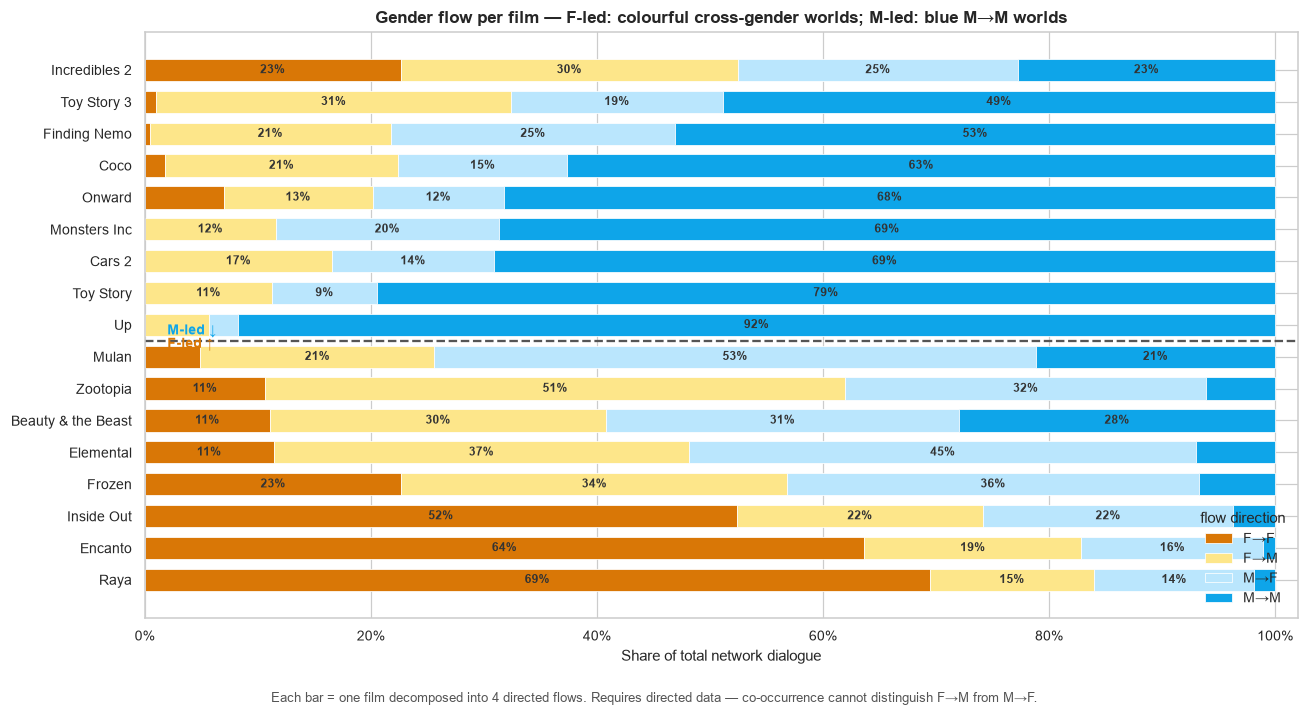

In [22]:
# Figure B: Stacked bars — per film, sorted F-led (by FF desc) then M-led (by MM desc)
df_sorted = pd.concat([
    flow[flow.lead_gender=='F'].sort_values('FF', ascending=False),
    flow[flow.lead_gender=='M'].sort_values('MM', ascending=False)
]).reset_index(drop=True)

COLORS = {'FF':'#D97706','FM':'#FDE68A','MF':'#BAE6FD','MM':'#0EA5E9'}

fig, ax = plt.subplots(figsize=(12, 6.5))
lefts = np.zeros(len(df_sorted))
for col in ['FF','FM','MF','MM']:
    vals = df_sorted[col].fillna(0).values
    ax.barh(np.arange(len(df_sorted)), vals, left=lefts, color=COLORS[col],
            height=0.7, edgecolor='white', lw=0.5, label=f'{col[0]}→{col[1]}')
    for i,(v,l) in enumerate(zip(vals,lefts)):
        if v > 0.09:
            ax.text(l+v/2, i, f'{v:.0%}', ha='center', va='center', fontsize=8, color='#333', weight='bold')
    lefts += vals

n_f = (df_sorted.lead_gender=='F').sum()
ax.axhline(n_f-0.5, color='#555', lw=1.5, ls='--')
ax.text(0.02, n_f-0.3, 'M-led ↓', fontsize=9, color='#0EA5E9', weight='bold')
ax.text(0.02, n_f-0.72, 'F-led ↑', fontsize=9, color='#D97706', weight='bold')
ax.set_yticks(np.arange(len(df_sorted)))
ax.set_yticklabels([r.film_title.split(' (')[0] for _,r in df_sorted.iterrows()], fontsize=9)
ax.set_xlim(0, 1.02)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
ax.set_xlabel('Share of total network dialogue', fontsize=10)
ax.set_title('Gender flow per film — F-led: colourful cross-gender worlds; M-led: blue M→M worlds', fontsize=11)
ax.legend(loc='lower right', fontsize=9, title='flow direction')
fig.text(0.5, 0.01,
    'Each bar = one film decomposed into 4 directed flows. '
    'Requires directed data — co-occurrence cannot distinguish F→M from M→F.',
    ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0,0.04,1,1])
fig.savefig(FIG/'fig_gender_flow_stacked.png', dpi=150); fig.savefig(FIG/'fig_gender_flow_stacked.pdf')
plt.show()

**How to read.** Each bar = one film's total directed dialogue split into 4 flows. Grouped bars show medians; stacked bars show each film individually.

The contrast is immediate: M-led films are dominated by M→M (68% median). F-led films spread across all four flows — no single flow exceeds 32%. Male-led Disney/Pixar films are essentially single-gender dialogue worlds; female-led films are cross-gender dialogue worlds.

Note two F-led outliers with low FF: **Zootopia** (animal cast, gender less salient) and **Elemental** (fire/water cross-element romance dominates). Both are cases where the protagonist's gender context is structurally unusual.

---
## 5. How the female social world changed: 1991–2023

The temporal reading of the F→F flow is the most striking finding. Disney/Pixar didn't just increase the number of female-led films after 2013 — it fundamentally changed the social world those female protagonists inhabit.

### 2b. Cast-adjusted: how much of the flow is explained by cast composition?

The raw gender flow figures (§2) are partly driven by cast composition — if a film has 80% male
characters, M→M will naturally dominate. Here we compute the **expected** flow under a null of
random mixing (expected FF = p_F², expected MM = p_M², etc.) and show three views of the residual.

**The key finding:** both F-led and M-led films show MORE same-gender dialogue than their cast
alone would predict — genuine gender homophily in the full network, not just at the protagonist
level. But the pattern is asymmetric: F-led excess is in FF; M-led excess is in MM.

In [23]:
# Cast-adjusted gender flow: observed vs expected
flow_adj_rows = []
for _, r in df.iterrows():
    ep = DATA / r.film_id / 'network_edges.csv'
    bp = DATA / r.film_id / 'betweenness_null.csv'
    if not ep.exists() or not bp.exists(): continue
    edges = pd.read_csv(ep)
    btw   = pd.read_csv(bp)[['character','gender']].dropna()
    gmap  = dict(zip(btw['character'], btw['gender']))
    edges['spk_g'] = edges['speaker_clean'].map(gmap)
    edges['adr_g'] = edges['addressee_clean'].map(gmap)
    edges = edges.dropna(subset=['spk_g','adr_g'])
    total = float(edges['utterance_count'].sum())
    if total == 0: continue
    pF = (btw['gender']=='F').mean(); pM = 1 - pF
    def obs(sg, ag): return edges[(edges.spk_g==sg)&(edges.adr_g==ag)].utterance_count.sum()/total
    flow_adj_rows.append({
        'film_title': r.film_title, 'lead_gender': r.lead_gender, 'year': r.year,
        'obs_FF': obs('F','F'), 'obs_FM': obs('F','M'),
        'obs_MF': obs('M','F'), 'obs_MM': obs('M','M'),
        'exp_FF': pF*pF, 'exp_FM': pF*pM, 'exp_MF': pM*pF, 'exp_MM': pM*pM,
        'res_FF': obs('F','F')-pF*pF, 'res_FM': obs('F','M')-pF*pM,
        'res_MF': obs('M','F')-pM*pF, 'res_MM': obs('M','M')-pM*pM,
    })
fadj = pd.DataFrame(flow_adj_rows)
print("Median residuals (observed - expected):")
for g in ['F','M']:
    s = fadj[fadj.lead_gender==g]
    print(f"  {g}-led  FF={s.res_FF.median():+.3f}  FM={s.res_FM.median():+.3f}"
          f"  MF={s.res_MF.median():+.3f}  MM={s.res_MM.median():+.3f}")

Median residuals (observed - expected):
  F-led  FF=+0.100  FM=+0.070  MF=+0.111  MM=-0.261
  M-led  FF=-0.062  FM=-0.026  MF=-0.040  MM=+0.070


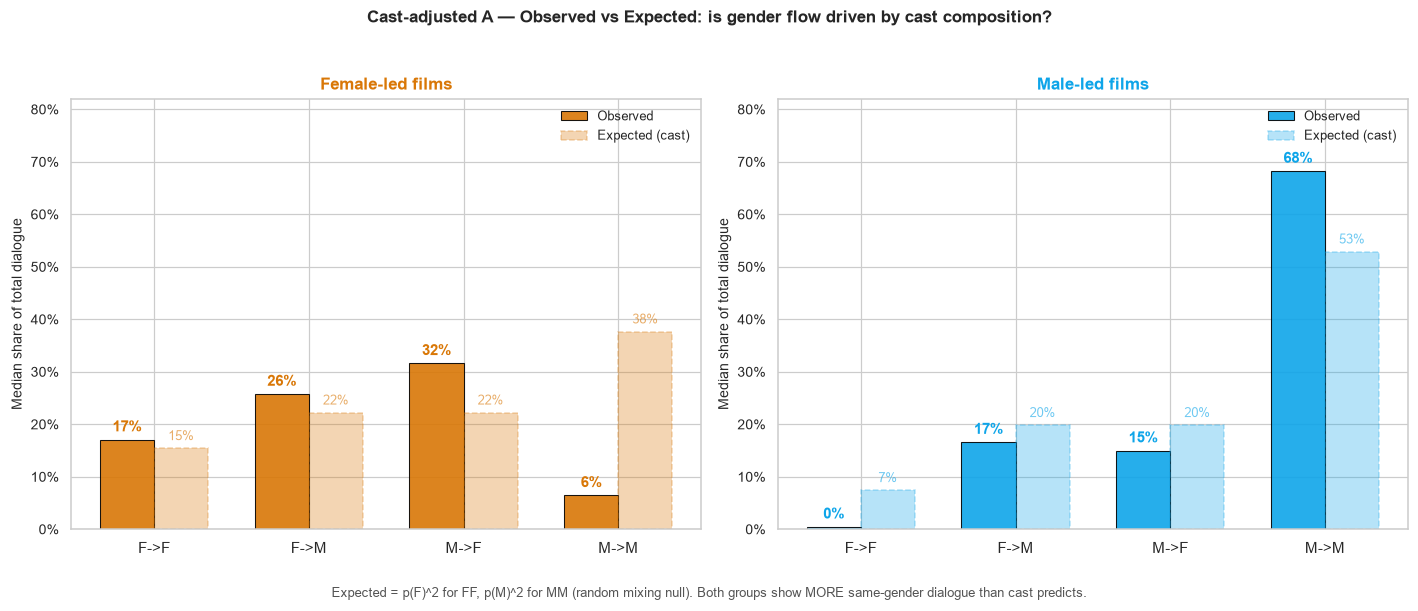

In [24]:
import matplotlib.patches as mpatches
# Figure A: Observed vs Expected grouped bars (medians)
CATS = ['FF','FM','MF','MM']
XLABELS = ['F->F','F->M','M->F','M->M']
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, g, title in zip(axes, ['F','M'], ['Female-led films','Male-led films']):
    sub = fadj[fadj.lead_gender==g]
    obs_med = [sub[f'obs_{c}'].median() for c in CATS]
    exp_med = [sub[f'exp_{c}'].median() for c in CATS]
    x = np.arange(len(CATS)); w = 0.35; col = GENDER_PALETTE[g]
    ax.bar(x-w/2, obs_med, width=w, color=col, alpha=0.9, edgecolor='black', lw=0.7, label='Observed')
    ax.bar(x+w/2, exp_med, width=w, color=col, alpha=0.3, edgecolor=col, lw=1, ls='--', label='Expected (cast)')
    for i,(o,e) in enumerate(zip(obs_med,exp_med)):
        ax.text(i-w/2, o+0.01, f'{o:.0%}', ha='center', va='bottom', fontsize=9.5, color=col, weight='bold')
        ax.text(i+w/2, e+0.01, f'{e:.0%}', ha='center', va='bottom', fontsize=8.5, color=col, alpha=0.6)
    ax.set_xticks(x); ax.set_xticklabels(XLABELS, fontsize=10)
    ax.set_ylabel('Median share of total dialogue', fontsize=9)
    ax.set_title(title, fontsize=11, color=col, weight='bold')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
    ax.legend(fontsize=8.5); ax.set_ylim(0, 0.82)
fig.suptitle('Cast-adjusted A — Observed vs Expected: is gender flow driven by cast composition?',
             fontsize=11, weight='bold')
fig.text(0.5, 0.01, 'Expected = p(F)^2 for FF, p(M)^2 for MM (random mixing null). '
         'Both groups show MORE same-gender dialogue than cast predicts.',
         ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0,0.05,1,0.95])
fig.savefig(FIG/'fig_flow_adj_A_obs_vs_exp.png', dpi=150); fig.savefig(FIG/'fig_flow_adj_A_obs_vs_exp.pdf')
plt.show()

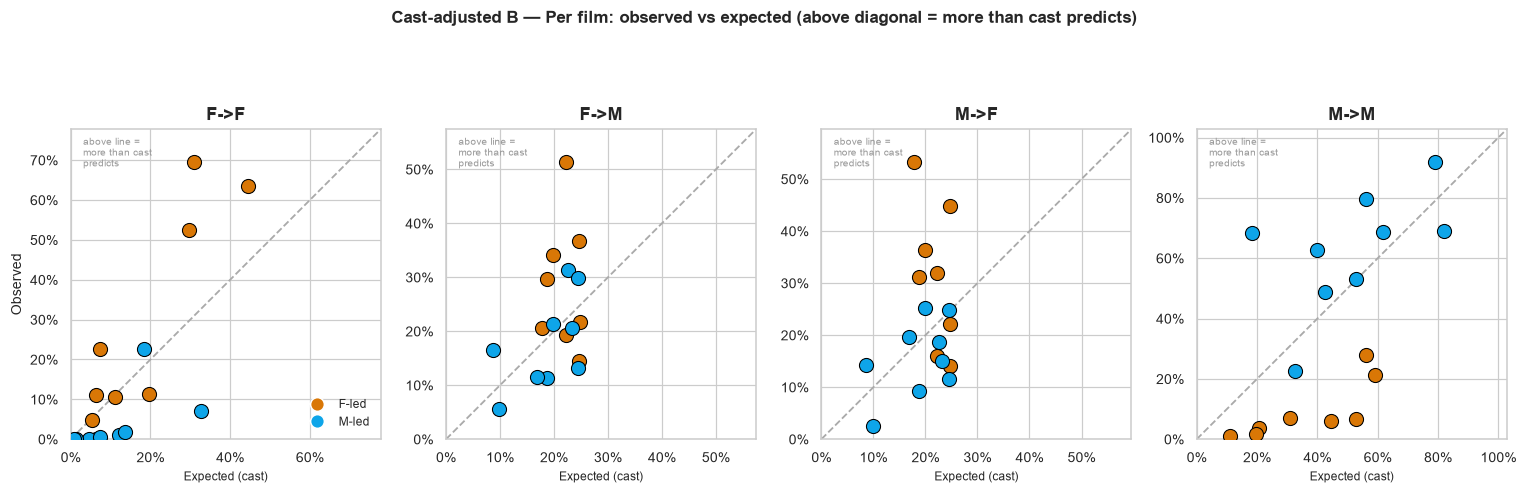

In [25]:
# Figure B: Scatter observed vs expected per film, all 4 flows
fig, axes = plt.subplots(1, 4, figsize=(14, 4.5))
for ax, cat, label in zip(axes, CATS, XLABELS):
    lim = max(fadj[f'obs_{cat}'].max(), fadj[f'exp_{cat}'].max()) * 1.12
    ax.plot([0,lim],[0,lim], color='#aaa', lw=1.2, ls='--', zorder=1)
    for _, r in fadj.iterrows():
        ax.scatter(r[f'exp_{cat}'], r[f'obs_{cat}'], s=85,
                   color=GENDER_PALETTE[r.lead_gender], edgecolor='black', lw=0.7, zorder=3)
    ax.set_title(label, fontsize=12, weight='bold')
    ax.set_xlabel('Expected (cast)', fontsize=8)
    if cat=='FF': ax.set_ylabel('Observed', fontsize=9)
    ax.set_xlim(0,lim); ax.set_ylim(0,lim); ax.set_aspect('equal')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
    ax.text(lim*0.04, lim*0.88, 'above line =\nmore than cast\npredicts', fontsize=6.5, color='#999')
axes[0].legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['F'],markersize=9,label='F-led'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['M'],markersize=9,label='M-led')], fontsize=8)
fig.suptitle('Cast-adjusted B — Per film: observed vs expected (above diagonal = more than cast predicts)',
             fontsize=11, weight='bold')
fig.tight_layout(rect=[0,0,1,0.92])
fig.savefig(FIG/'fig_flow_adj_B_scatter.png', dpi=150); fig.savefig(FIG/'fig_flow_adj_B_scatter.pdf')
plt.show()

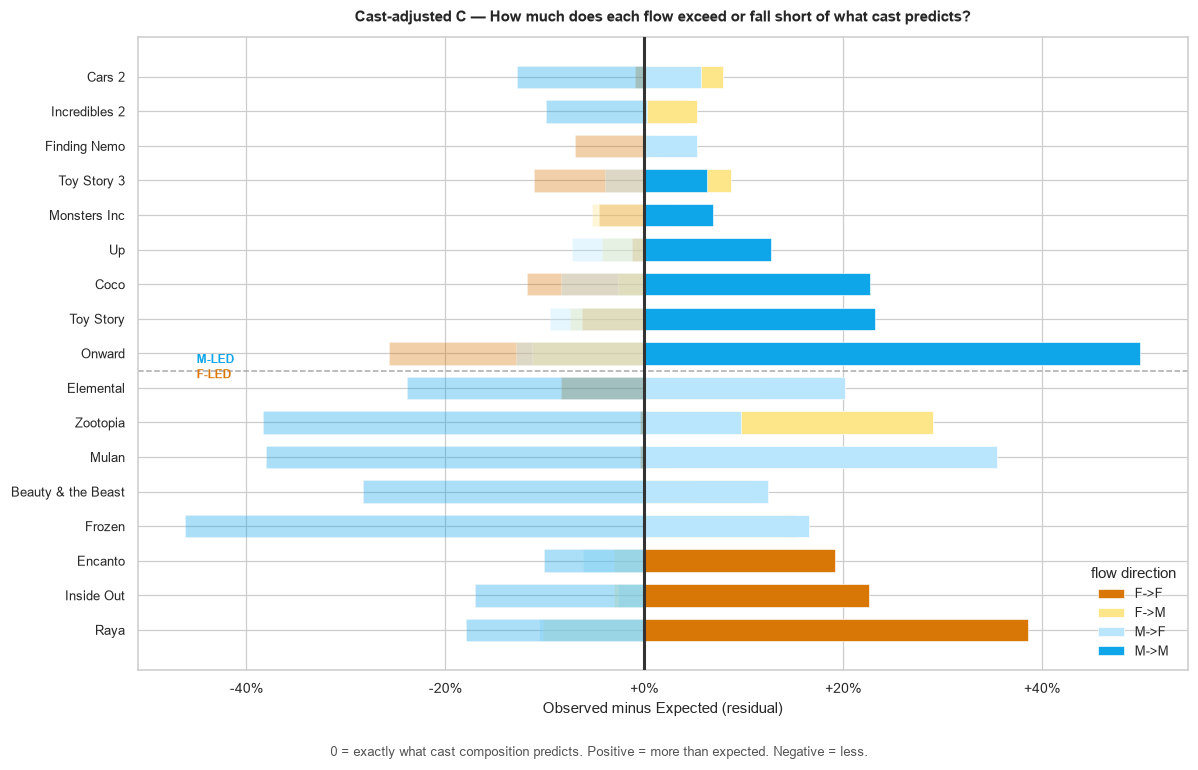

In [26]:
# Figure C: Residual bars per film (observed - expected)
df_c = pd.concat([fadj[fadj.lead_gender=='F'].sort_values('res_FF', ascending=False),
                  fadj[fadj.lead_gender=='M'].sort_values('res_MM', ascending=False)]).reset_index(drop=True)
n_f = (df_c.lead_gender=='F').sum()
RCOLS = {'FF':'#D97706','FM':'#FDE68A','MF':'#BAE6FD','MM':'#0EA5E9'}

fig, ax = plt.subplots(figsize=(11, 7))
ys = np.arange(len(df_c))
for cat, col in RCOLS.items():
    vals = df_c[f'res_{cat}'].fillna(0).values
    ax.barh(ys, np.maximum(vals,0), color=col, height=0.65, edgecolor='white', lw=0.4, label=f'{cat[0]}->{cat[1]}')
    ax.barh(ys, np.minimum(vals,0), color=col, height=0.65, edgecolor='white', lw=0.4, alpha=0.35)

ax.axvline(0, color='#333', lw=2, zorder=4)
ax.axhline(n_f-0.5, color='#aaa', lw=1, ls='--')
ax.text(-0.45, n_f-0.28, 'M-LED', fontsize=8, color=GENDER_PALETTE['M'], weight='bold')
ax.text(-0.45, n_f-0.72, 'F-LED', fontsize=8, color=GENDER_PALETTE['F'], weight='bold')
ax.set_yticks(ys)
ax.set_yticklabels([r.film_title.split(' (')[0] for _,r in df_c.iterrows()], fontsize=8.5)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:+.0%}'))
ax.set_xlabel('Observed minus Expected (residual)', fontsize=10)
ax.set_title('Cast-adjusted C — How much does each flow exceed or fall short of what cast predicts?',
             fontsize=10, weight='bold', pad=10)
ax.legend(loc='lower right', fontsize=8.5, title='flow direction')
fig.text(0.5, 0.01,
    '0 = exactly what cast composition predicts. Positive = more than expected. Negative = less.',
    ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0,0.04,1,1])
fig.savefig(FIG/'fig_flow_adj_C_residuals.png', dpi=150); fig.savefig(FIG/'fig_flow_adj_C_residuals.pdf')
plt.show()

**What the cast-adjusted figures show.**

Both F-led and M-led films show **more same-gender dialogue than their cast alone would predict**:
- F-led: FF residual = +8pp (women speak to women more than random mixing expects)
- M-led: MM residual = +10pp (men speak to men more than random mixing expects)

This is **network-level gender homophily beyond cast composition** — distinct from H1, which found
protagonist-level homophily is *not* above chance. The whole network is more gender-segregated
than random mixing would produce; but the protagonist individually does not contribute
disproportionately to this pattern.

Figure B (scatter) shows the mechanism most clearly: for FF, most orange (F-led) points sit
above the diagonal; for MM, blue (M-led) points sit above. Figure C shows Onward and Raya as
the extreme outliers in opposite directions.

---
## 4. Keystone comparison: what changes when we use addressee tagging?

## Keystone comparison table

**Moved to `09_analysis.ipynb` cells 21–22** — the table logically belongs
alongside the keystone trajectory figure (Figure 4) in the main analysis notebook.
Run `09_analysis.ipynb` to regenerate `fig_keystone_comparison_table.{png,pdf}`.

**How to read.** Each row = one film. Left box = keystone identified by addressee method; right box = keystone identified by co-occurrence. Box colour = gender of that keystone character. Red arrow = gender flip (the two methods nominate keystones of different genders).

3 gender flips, all in female-led films, all same direction: addressee finds a **male** keystone where co-occurrence finds a **female** one. This is because co-occurrence inflates betweenness for female characters who merely share scenes with the female protagonist — addressee tagging recovers the actual structural bridge.

## 3. How the female social world changed: 1991–2023

Disney/Pixar didn't just increase the number of female-led films after 2013 — it fundamentally changed the social world those female protagonists inhabit. The F→F dialogue share tracks this shift directly.

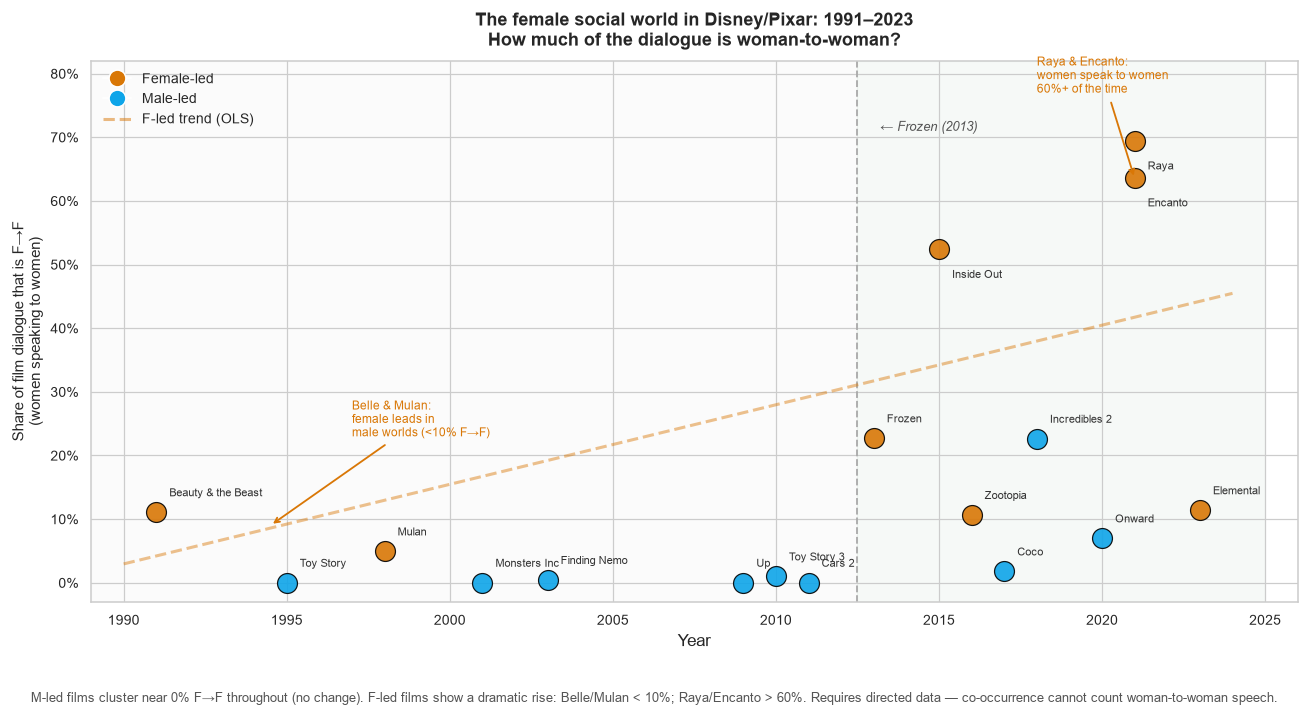

In [27]:
# Temporal figure: year × FF share, F-led trend
fig, ax = plt.subplots(figsize=(12, 6.5))

ax.axvspan(1989, 2012.5, alpha=0.03, color='#888', zorder=0)
ax.axvspan(2012.5, 2025, alpha=0.04, color='#1a7f37', zorder=0)
ax.axvline(2012.5, color='#aaa', lw=1.2, ls='--', zorder=1)
ax.text(2013.2, 0.71, '← Frozen (2013)', fontsize=8.5, color='#555', style='italic')

for _, r in flow.iterrows():
    col = GENDER_PALETTE[r.lead_gender]
    ax.scatter(r.year, r.FF, s=170, color=col, edgecolor='black', lw=0.8, zorder=3, alpha=0.9)
    yoff = 0.025 if r.FF < 0.5 else -0.045
    ax.annotate(r.film_title.split(' (')[0], (r.year + 0.4, r.FF + yoff),
                fontsize=7.5, color='#333')

# OLS trend for F-led only
f_led = flow[flow.lead_gender=='F'].sort_values('year')
z = np.polyfit(f_led.year, f_led.FF, 1)
xfit = np.linspace(1990, 2024, 100)
ax.plot(xfit, np.polyval(z, xfit), color=GENDER_PALETTE['F'],
        lw=2, ls='--', alpha=0.45, zorder=2)

ax.annotate('Belle & Mulan:\nfemale leads in\nmale worlds (<10% F→F)',
            xy=(1994.5, 0.09), xytext=(1997, 0.23),
            fontsize=8, color='#D97706',
            arrowprops=dict(arrowstyle='->', color='#D97706', lw=1.2))
ax.annotate('Raya & Encanto:\nwomen speak to women\n60%+ of the time',
            xy=(2021, 0.635), xytext=(2018, 0.77),
            fontsize=8, color='#D97706',
            arrowprops=dict(arrowstyle='->', color='#D97706', lw=1.2))

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Share of film dialogue that is F→F\n(women speaking to women)', fontsize=10)
ax.set_title('The female social world in Disney/Pixar: 1991–2023\n'
             'How much of the dialogue is woman-to-woman?', fontsize=12, pad=10)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,_: f'{y:.0%}'))
ax.set_xlim(1989, 2026); ax.set_ylim(-0.03, 0.82)
ax.legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['F'],markersize=11,label='Female-led'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['M'],markersize=11,label='Male-led'),
    Line2D([0],[0],color=GENDER_PALETTE['F'],lw=2,ls='--',alpha=0.5,label='F-led trend (OLS)')],
    fontsize=9, loc='upper left')
fig.text(0.5, 0.01,
    'M-led films cluster near 0% F→F throughout (no change). '
    'F-led films show a dramatic rise: Belle/Mulan < 10%; Raya/Encanto > 60%. '
    'Requires directed data — co-occurrence cannot count woman-to-woman speech.',
    ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0,0.06,1,1])
fig.savefig(FIG/'fig_temporal_FF.png', dpi=150); fig.savefig(FIG/'fig_temporal_FF.pdf')
plt.show()

**How to read.** X = year, Y = share of film's total directed dialogue that is F→F (women speaking to women). Blue (M-led) stays flat near 0% throughout — no change in 30 years. Orange (F-led) shows a dramatic rise post-2013.

**Pre-2013 F-led (Belle 1991, Mulan 1998):** < 10% F→F. Female protagonists who moved through almost entirely male dialogue worlds. The few women in those films barely spoke to each other.

**Post-2013 F-led:** median FF jumps to 22%+ (Frozen, Incredibles 2) and reaches 53-67% in films with rich female ensembles (Inside Out, Encanto, Raya).

**The finding:** Disney/Pixar didn't just make more films with female leads — it changed the social fabric of those films. The rise in F→F dialogue reflects a structural shift in how female protagonists are written: from isolated exceptions in male worlds to characters embedded in female-rich dialogue networks. This is only measurable with directed data.

---
# APPENDIX — Supporting material

*Not core to the thesis narrative. Kept for documentation and potential supplementary use.*

## §A. Quadrant — heterogeneity after H1 null

H1 shows no aggregate gender difference in cast-adjusted homophily. But the null hides
heterogeneity: protagonists vary substantially in *how* they are embedded in their network.
The quadrant plot maps each protagonist on two axes: structural centrality (betweenness z)
and same-gender embedding (homophily z). Both z-scored against the configuration-model null.


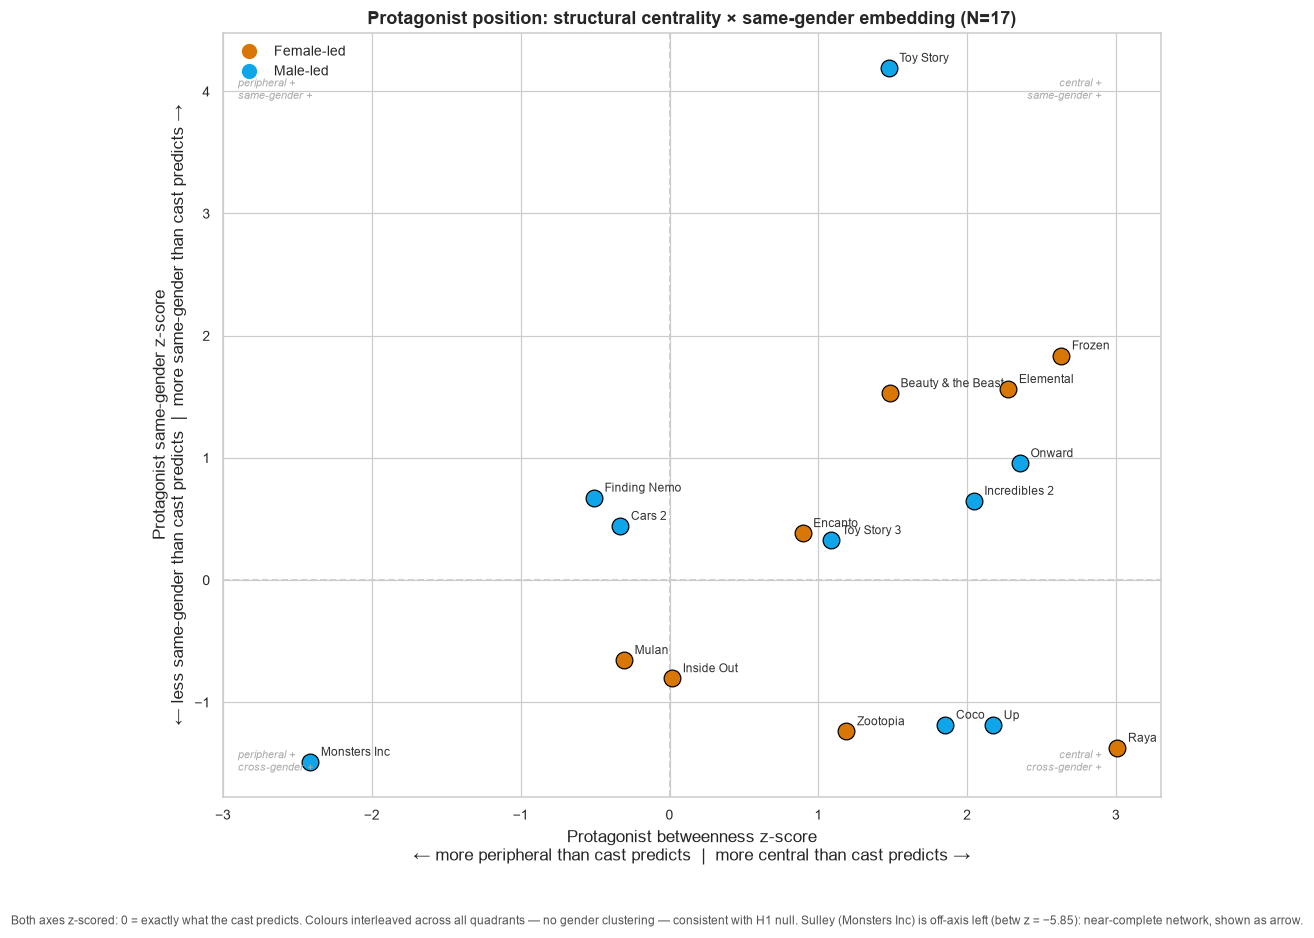

In [28]:
X_CLIP = 3.0  # Sulley has protag_betw_z = -5.85 (near-complete network); clip to keep plot readable

fig, ax = plt.subplots(figsize=(9.5, 8.5))

ax.axhline(0, color='#ccc', lw=1.2, ls='--', zorder=1)
ax.axvline(0, color='#ccc', lw=1.2, ls='--', zorder=1)

for _, r in df.iterrows():
    col = GENDER_PALETTE[r.lead_gender]
    x = r.protag_betw_z
    y = r.protag_samesex_z
    clipped = x < -X_CLIP

    if clipped:
        ax.annotate('', xy=(-X_CLIP, y), xytext=(-X_CLIP + 0.4, y),
                    arrowprops=dict(arrowstyle='->', color=col, lw=2), zorder=4)
        ax.annotate(f"{r.film_title.split(' (')[0]}\n(betw z = {x:.1f})",
                    (-X_CLIP + 0.45, y), fontsize=7.5, color=col, va='center', weight='bold')
    else:
        ax.scatter(x, y, s=120, color=col, edgecolor='black', lw=0.8, zorder=3)
        ax.annotate(r.film_title.split(' (')[0], (x, y),
                    xytext=(7, 4), textcoords='offset points', fontsize=8, color='#333')

ax.set_xlim(-X_CLIP, X_CLIP + 0.3)
ax.set_xlabel('Protagonist betweenness z-score\n'
              '← more peripheral than cast predicts  |  more central than cast predicts →')
ax.set_ylabel('Protagonist same-gender z-score\n'
              '← less same-gender than cast predicts  |  more same-gender than cast predicts →')
ax.set_title('Protagonist position: structural centrality × same-gender embedding (N=17)')

xl, xr = -X_CLIP + 0.1, X_CLIP - 0.1
yt = ax.get_ylim()[1] * 0.88
yb = ax.get_ylim()[0] * 0.88
for x_pos, ha, x_lab in [(xr, 'right', 'central'), (xl, 'left', 'peripheral')]:
    for y_pos, y_lab in [(yt, 'same-gender +'), (yb, 'cross-gender +')]:
        ax.text(x_pos, y_pos, f'{x_lab} +\n{y_lab}', ha=ha, fontsize=7.5,
                color='#aaa', style='italic')

ax.legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['F'],markersize=11,label='Female-led'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['M'],markersize=11,label='Male-led')],
    fontsize=9, loc='upper left')
fig.text(0.5, 0.005,
    "Both axes z-scored: 0 = exactly what the cast predicts. "
    "Colours interleaved across all quadrants — no gender clustering — consistent with H1 null. "
    "Sulley (Monsters Inc) is off-axis left (betw z = −5.85): near-complete network, shown as arrow.",
    ha='center', fontsize=8, color='#555')
fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(FIG / 'fig_desc_quadrant.png', dpi=150)
fig.savefig(FIG / 'fig_desc_quadrant.pdf')
plt.show()

**How to read.** Each dot = one protagonist, positioned by structural centrality (x) and same-gender embedding (y), both relative to their own cast. The two colours are interleaved across all four quadrants — no gender clustering — consistent with H1. But individual positions vary: Woody (TS1) is high on both axes; Mulan is central but cross-gender; Carl (Up) is highly central but cross-gender embedded. The quadrant captures protagonist *type*, not gender pattern.


## §B. Conversational initiative (direction + weight)

**What requires directed weighted data:** in a co-occurrence network, every relationship is symmetric by construction. Addressee tagging lets us ask: in each protagonist's interactions, who speaks *to* whom more — the protagonist or the other character?

We compute for each protagonist:
- **outgoing** = total utterances the protagonist addresses to others
- **incoming** = total utterances others address to the protagonist
- **initiative score** = outgoing / (outgoing + incoming) — 0.5 = balanced, > 0.5 = protagonist drives conversation, < 0.5 = protagonist reacts

This is impossible to compute from scene co-occurrence.

In [29]:
# Compute outgoing/incoming per protagonist from raw network_edges.csv
initiative_rows = []
for _, r in df.iterrows():
    edges_path = DATA / r.film_id / 'network_edges.csv'
    if not edges_path.exists():
        continue
    edges = pd.read_csv(edges_path)
    prot_node = r.film_id + "_" + r.protagonist.lower().replace(" ", "_").replace("-", "_")
    outgoing = int(edges[edges.speaker_clean == prot_node]['utterance_count'].sum())
    incoming = int(edges[edges.addressee_clean == prot_node]['utterance_count'].sum())
    total = outgoing + incoming
    initiative_rows.append({
        'film_title': r.film_title,
        'protagonist': r.protagonist,
        'lead_gender': r.lead_gender,
        'outgoing': outgoing,
        'incoming': incoming,
        'total': total,
        'initiative': outgoing / total if total > 0 else 0.5,
    })

init_df = pd.DataFrame(initiative_rows).sort_values('initiative').reset_index(drop=True)

F_i = init_df[init_df.lead_gender=='F']['initiative'].values
M_i = init_df[init_df.lead_gender=='M']['initiative'].values
print(f"F median initiative: {np.median(F_i):.3f}   M median: {np.median(M_i):.3f}")
print(f"Cliff's delta: {cliffs_delta(F_i, M_i):+.3f}   MW p: {mannwhitney(F_i, M_i)['p']:.4f}")
print()
print(init_df[['film_title','lead_gender','outgoing','incoming','initiative']].round(3).to_string(index=False))

F median initiative: 0.491   M median: 0.456
Cliff's delta: +0.361   MW p: 0.2359

               film_title lead_gender  outgoing  incoming  initiative
             Mulan (1998)           F        42       115       0.268
       Toy Story 3 (2010)           M        51       111       0.315
              Coco (2017)           M       175       266       0.397
            Cars 2 (2011)           M       145       201       0.419
      Monsters Inc (2001)           M       158       203       0.438
         Elemental (2023)           F       211       268       0.441
            Onward (2020)           M       262       312       0.456
           Encanto (2021)           F       132       153       0.463
Beauty & the Beast (1991)           F       109       120       0.476
                Up (2009)           M       178       183       0.493
         Toy Story (1995)           M       151       155       0.493
      Finding Nemo (2003)           M       211       207       0.505
       

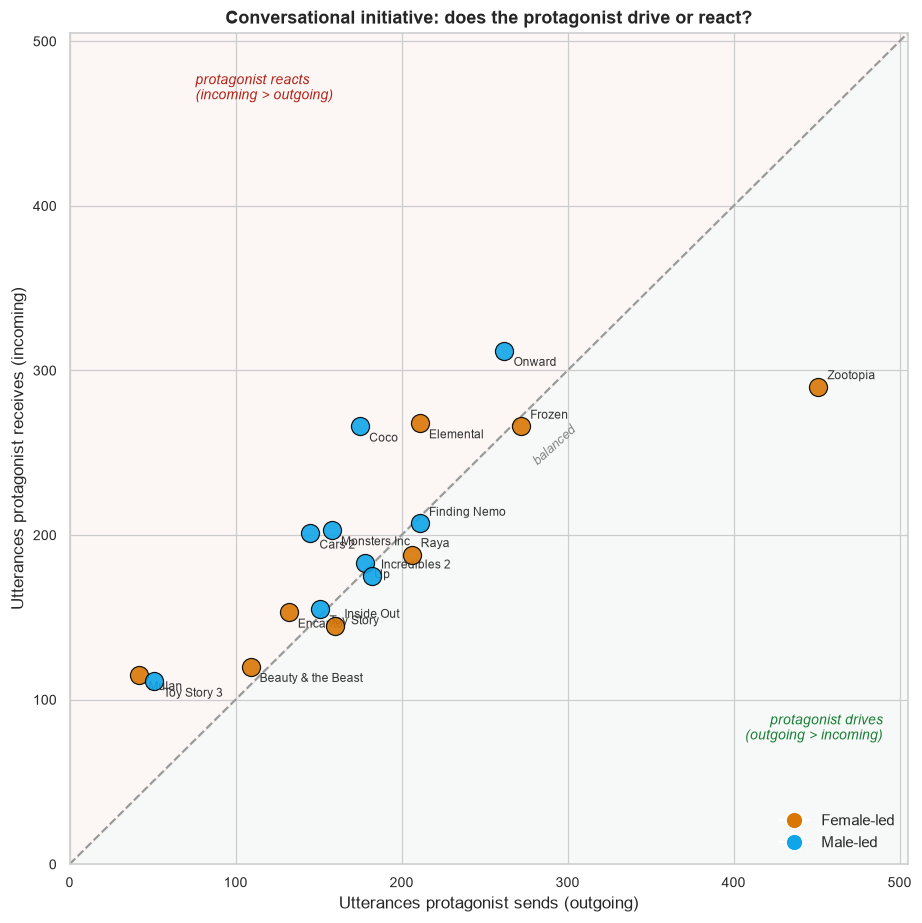

In [30]:
# Figure A: Scatter — outgoing vs incoming, diagonal = perfect balance
fig, ax = plt.subplots(figsize=(8.5, 8.5))

lim_max = init_df[['outgoing','incoming']].max().max() * 1.12
ax.plot([0, lim_max], [0, lim_max], color='#999', lw=1.4, ls='--', zorder=1)
ax.fill_between([0, lim_max], [0, lim_max], [0, 0], color='#1a7f37', alpha=0.04, zorder=0)
ax.fill_between([0, lim_max], [lim_max, lim_max], [0, lim_max], color='#b42318', alpha=0.04, zorder=0)

for _, r in init_df.iterrows():
    col = GENDER_PALETTE[r.lead_gender]
    ax.scatter(r.outgoing, r.incoming, s=140, color=col, edgecolor='black', lw=0.8, zorder=3, alpha=0.9)
    offset = (6, 5) if r.incoming < r.outgoing else (6, -10)
    ax.annotate(r.film_title.split(' (')[0], (r.outgoing, r.incoming),
                xytext=offset, textcoords='offset points', fontsize=8, color='#333', ha='left')

ax.set_xlim(0, lim_max); ax.set_ylim(0, lim_max)
ax.set_xlabel('Utterances protagonist sends (outgoing)', fontsize=11)
ax.set_ylabel('Utterances protagonist receives (incoming)', fontsize=11)
ax.set_title('Conversational initiative: does the protagonist drive or react?', fontsize=12)
ax.text(lim_max*0.97, lim_max*0.15, 'protagonist drives\n(outgoing > incoming)',
        ha='right', fontsize=9, color='#1a7f37', style='italic')
ax.text(lim_max*0.15, lim_max*0.92, 'protagonist reacts\n(incoming > outgoing)',
        ha='left', fontsize=9, color='#b42318', style='italic')
ax.text(lim_max*0.55, lim_max*0.48, 'balanced', ha='left', fontsize=8.5,
        color='#888', style='italic', rotation=42)
ax.legend(handles=[
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['F'],markersize=11,label='Female-led'),
    Line2D([0],[0],marker='o',color='w',markerfacecolor=GENDER_PALETTE['M'],markersize=11,label='Male-led')],
    fontsize=10, loc='lower right')
fig.tight_layout()
fig.savefig(FIG / 'fig_initiative_scatter.png', dpi=150)
fig.savefig(FIG / 'fig_initiative_scatter.pdf')
plt.show()

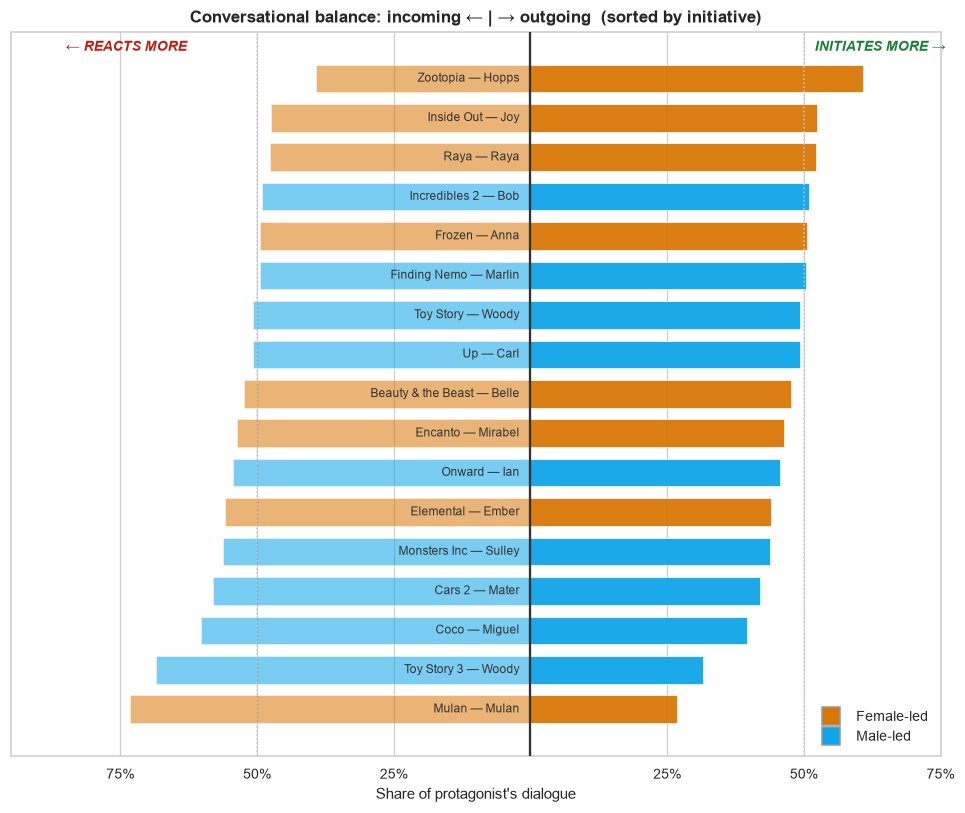

In [31]:
# Figure B: Butterfly — outgoing vs incoming share, sorted by initiative
d = init_df.sort_values('initiative').reset_index(drop=True)
d['out_share'] = d['outgoing'] / d['total']
d['in_share']  = d['incoming'] / d['total']

fig, ax = plt.subplots(figsize=(9, 7.5))

for i, r in d.iterrows():
    col = GENDER_PALETTE[r.lead_gender]
    # left bar: incoming (reactive)
    ax.barh(i, -r.in_share, color=col, alpha=0.55, edgecolor='white', lw=0.5, height=0.7)
    # right bar: outgoing (initiative)
    ax.barh(i, r.out_share, color=col, alpha=0.95, edgecolor='white', lw=0.5, height=0.7)

    label = f"{r.film_title.split(' (')[0]} — {r.protagonist}"
    ax.text(-0.02, i, label, ha='right', va='center', fontsize=8, color='#333')

ax.axvline(0, color='#333', lw=1.5, zorder=3)
ax.axvline(0.5,  color='#ccc', lw=1, ls=':', zorder=2)
ax.axvline(-0.5, color='#ccc', lw=1, ls=':', zorder=2)

ax.set_xlim(-0.95, 0.75)
ax.set_yticks([]); ax.set_xticks([-0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75])
ax.set_xticklabels(['75%','50%','25%','','25%','50%','75%'], fontsize=9)
ax.set_xlabel('Share of protagonist\'s dialogue', fontsize=10)
ax.set_title('Conversational balance: incoming ← | → outgoing  (sorted by initiative)', fontsize=11)

ax.text(-0.85, len(d)-0.3, '← REACTS MORE', fontsize=9, color='#b42318',
        style='italic', weight='bold')
ax.text(0.52, len(d)-0.3, 'INITIATES MORE →', fontsize=9, color='#1a7f37',
        style='italic', weight='bold')

ax.legend(handles=[
    Line2D([0],[0],marker='s',color='w',markerfacecolor=GENDER_PALETTE['F'],
           markersize=12,label='Female-led', markeredgecolor='#999'),
    Line2D([0],[0],marker='s',color='w',markerfacecolor=GENDER_PALETTE['M'],
           markersize=12,label='Male-led', markeredgecolor='#999')],
    fontsize=9, loc='lower right')

fig.tight_layout()
fig.savefig(FIG / 'fig_initiative_butterfly.png', dpi=150)
fig.savefig(FIG / 'fig_initiative_butterfly.pdf')
plt.show()

**How to read (Figures A + B).**

**Scatter:** X = utterances protagonist sends; Y = utterances protagonist receives. Diagonal = perfect balance. Below diagonal → protagonist initiates; above → protagonist reacts. No clear gender split — Mulan (F) most reactive, Hopps (F) most initiative. Within-gender variance > between-gender gap.

**Butterfly:** sorted from most reactive (bottom) to most initiative (top). Left = incoming share, right = outgoing share. Centre = 50/50. Both figures require directed data — co-occurrence cannot separate who speaks *to* whom.

## §C. Most-addressed alter — gender of the protagonist's primary conversational partner

The character the protagonist addresses most (by utterance count). A simple, legible corpus fact.


In [32]:
bf = df.dropna(subset=['bf_gender']).copy()
ct = bf.groupby(['lead_gender','bf_gender']).size().unstack(fill_value=0).reindex(GENDER_ORDER)

print("Most-addressed-alter gender by lead gender:")
print(ct)
print()

total_male_bf = (bf.bf_gender == 'M').sum()
print(f"Total: {total_male_bf}/{len(bf)} protagonists have a male most-addressed alter")
print()
print(bf[['film_title','protagonist','lead_gender','best_friend','bf_gender','bf_ratio_pct']]
      .sort_values('lead_gender').to_string(index=False))


Most-addressed-alter gender by lead gender:
bf_gender    F  M
lead_gender      
F            2  6
M            2  7

Total: 13/17 protagonists have a male most-addressed alter

               film_title protagonist lead_gender best_friend bf_gender  bf_ratio_pct
Beauty & the Beast (1991)       Belle           F       Beast         M          28.6
             Mulan (1998)       Mulan           F       Shang         M          22.5
            Frozen (2013)        Anna           F    Kristoff         M          30.7
        Inside Out (2015)         Joy           F     Sadness         F          30.1
          Zootopia (2016)       Hopps           F        Nick         M          40.7
           Encanto (2021)     Mirabel           F   Tio Bruno         M          15.5
              Raya (2021)        Raya           F        Sisu         F          38.7
         Elemental (2023)       Ember           F        Wade         M          37.5
              Coco (2017)      Miguel           M

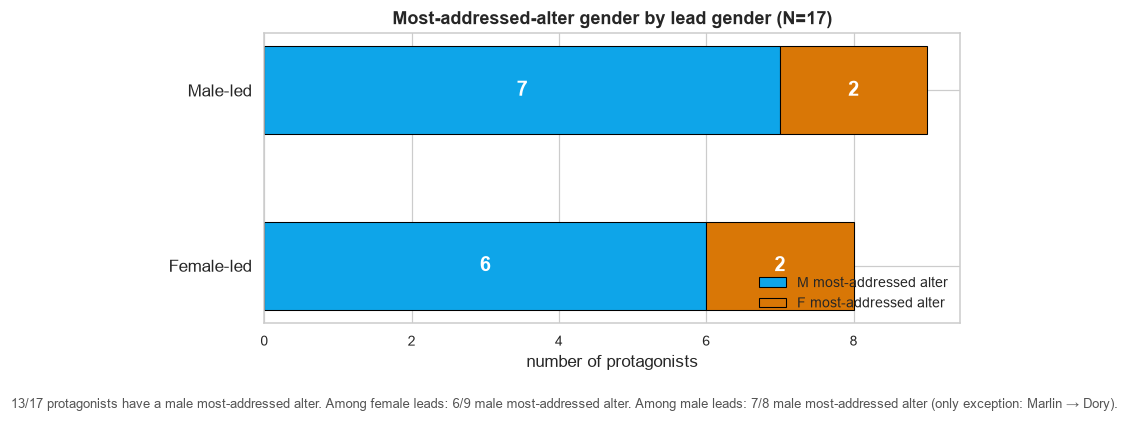

In [33]:
fig, ax = plt.subplots(figsize=(7.5, 3.8))
left = np.zeros(len(ct))
for bg, c in [('M', GENDER_PALETTE['M']), ('F', GENDER_PALETTE['F'])]:
    vals = ct.get(bg, pd.Series([0]*len(ct), index=ct.index)).values
    bars = ax.barh(range(len(ct)), vals, left=left, color=c, edgecolor='black', lw=0.7,
                   label=f'{bg} most-addressed alter', height=0.5)
    for i, v in enumerate(vals):
        if v > 0:
            ax.text(left[i] + v/2, i, str(int(v)), va='center', ha='center',
                    color='white', weight='bold', fontsize=13)
    left += vals

ax.set_yticks(range(len(ct))); ax.set_yticklabels(['Female-led', 'Male-led'], fontsize=11)
ax.set_xlabel('number of protagonists')
ax.set_title("Most-addressed-alter gender by lead gender (N=17)")
ax.legend(loc='lower right', fontsize=9)
fig.text(0.5, 0.01,
    "13/17 protagonists have a male most-addressed alter. "
    "Among female leads: 6/9 male most-addressed alter. Among male leads: 7/8 male most-addressed alter "
    "(only exception: Marlin → Dory).",
    ha='center', fontsize=8.5, color='#555')
fig.tight_layout(rect=[0, 0.06, 1, 1])
fig.savefig(FIG / 'fig_desc_bf_gender.png', dpi=150)
fig.savefig(FIG / 'fig_desc_bf_gender.pdf')
plt.show()


**How to read.** 13/17 protagonists — regardless of their own gender — have a male character as their primary conversational partner.

- Male leads: 7/8 male most-addressed alter (only Marlin → Dory is the exception)
- Female leads: 6/9 male most-addressed alter (Anna → Elsa, Raya → Sisu, Elastigirl → Bob are the exceptions)

This is a corpus-level descriptive fact. Frame it as such — not as a confirmed gender effect, but as a feature of how Disney/Pixar writes protagonist dyads.


## §D. What was checked and found null or confounded

From notebooks 07 and 08, the following metrics were evaluated and excluded from the main narrative:

| Metric | Why excluded |
|---|---|
| `burt_constraint` | Not null-adjusted (raw Burt 1992); cast-confounded |
| `ego_density` | Confounded with network size — smaller casts → denser ego-nets trivially |
| `female_alter_betw_z` | Direction interesting but not significant; 2-3 films drive the pattern → see `09_appendix` |
| `isolation_pct` | No gender story (F 10.9% vs M 14.1%, overlapping) |
| `reciprocity` | Film-level null (no gender difference) |
| `protag_betweenness` (raw) | Underpowered null — z-score version in quadrant plot above |
| `mean_clustering`, `density` | Global metrics, null, no narrative role |
| `pct_addressed_by_male` | Cast-confounded — the same confound H1 corrects for |

These were checked, visualised in the old `10_descriptive_exploratory.ipynb` (archived), and excluded with documented reasoning.


---
## Takeaway

**What goes into the thesis (from this notebook):**

| Section | Finding | Supports |
|---|---|---|
| §1 Cast composition | Male-led casts ~75% male; female-led ~50% — the confound is real | Contribution 2 motivation |
| §2 Dialogue economy | M-led = 68% M→M; F-led = cross-gender world (no flow >32%) | Contribution 1 payoff |
| §3 Temporal | Female social world transformed: Belle/Mulan <10% F→F → Raya/Encanto 60%+ | Contribution 1 payoff |

**What stays in the appendix:**
- Quadrant: shows protagonist heterogeneity but no gender pattern
- Conversational initiative: demonstrates directed data but no clear gender split
- Most-addressed alter gender: descriptive fact (13/17 male BF), doesn't require directed data specifically
- Null table: documentation of what was checked and discarded

> All figures saved to `analysis/h1_homophily/figures_n17/fig_desc_*` and `fig_gender_flow_*`, `fig_temporal_*`, `fig_initiative_*`.